In [1]:
from myutils import *
from scipy.optimize import minimize
from src import LoadEstimates, MetaData, Estimates, FrequencyEstimation, qCMOS, DI, SPADE, DMD

In [2]:
def td_estimator(measurement, sample: np.ndarray, w = None, method='mle'):
        # from .core import DI, qCMOS

        origin_shape = sample.shape

        detectors = origin_shape[-1]
        works = np.prod(origin_shape[:-1])

        flatten_data = sample.reshape(-1, detectors)

        if method.lower() == 'simple':

            if measurement.lower() == 'di':
                temp = flatten_data / flatten_data.sum(axis=-1).reshape(-1, 1)
                x_axis = np.arange(detectors)
                time_domain = (temp @ x_axis)

            if measurement.lower() == 'spade':
                time_domain = sample[..., 1] - sample[..., 0]


        elif method.lower() == 'mle':
            _sigma = DI.SIGMA / qCMOS.PIXEL_SIZE

            if measurement.lower() == 'di':
                def _p(x, s, w):
                    return (1-w)/np.sqrt(tau*_sigma**2)*np.exp(-(x-s)**2/(2*_sigma**2)) + w/detectors

            elif measurement.lower() == 'spade':
                def _p(k, s, w):
                    return (1-w)/8*np.exp(-(s/(2*_sigma))**2)*(s/_sigma+2*(-1)**(k+1))**2 + w/detectors

            def _nll(data, w):
                axis = np.arange(detectors)
                return lambda s: - data.T @ np.log(_p(axis, s, w)) / data.sum()

            def _run_mle(data, w):
                # Use BFGS algorithm to minimize negative log-likelihood function.
                result = minimize(_nll(data, w), x0=detectors/2, method='BFGS')
                
                if result.success:
                    return result.x[0]
                else:
                    raise RuntimeError('not converged')
            
            if w is None:
                time_domain = [_run_mle(flatten_data[i], 0) for i in range(works)]
            else:
                w_set = np.ravel(w)
                time_domain = [_run_mle(flatten_data[i], w_set[i]) for i in range(works)]  

        return np.array(time_domain).reshape(*origin_shape[:-1])


In [25]:
raw = np.load(r'c:\Users\Administrator\Desktop\10.19\spade_0.1.npy')
meta = MetaData('SPADE', 0.1, 5 * DMD.PIXEL_SIZE / 2, np.load(r'c:\Users\Administrator\Desktop\10.19\timestamp_0.1.npy'))

c = FrequencyEstimation(raw, meta)

In [26]:
spade_td = td_estimator(c.metadata.measurement, c.cropped_data-200, c.noise_weight)

In [5]:
di_td = LoadEstimates(r'c:\Users\Administrator\Desktop\11.2\estimates\di_0.1.npz').time_domain

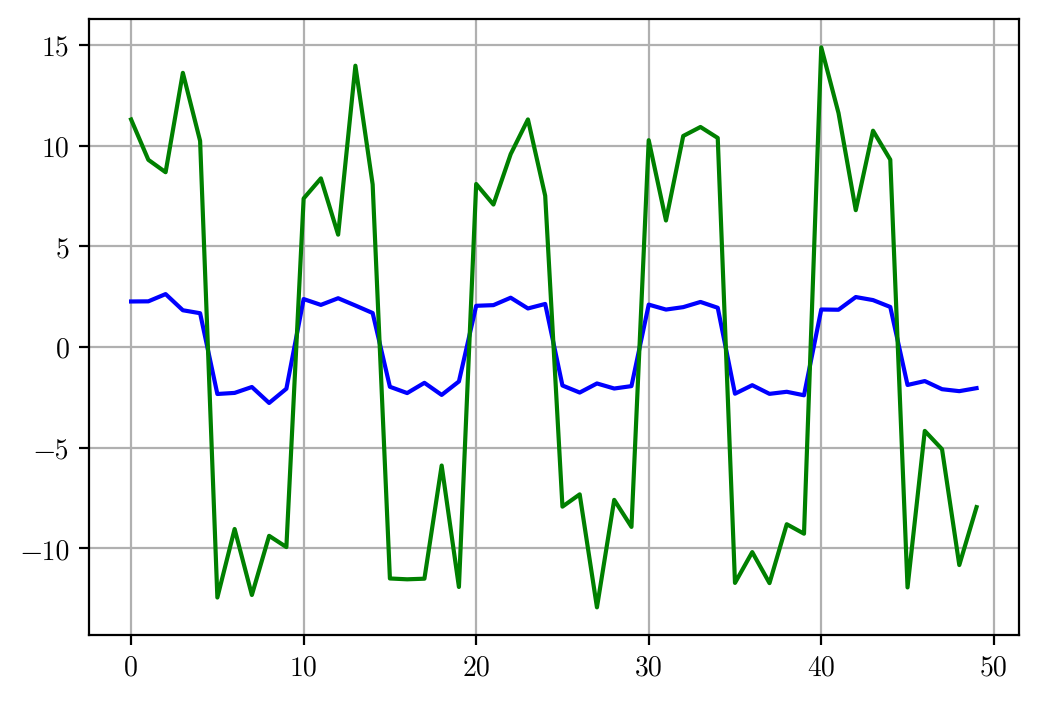

In [27]:
plot((di_td[0] - di_td[0].mean()))
plot((spade_td[0] - spade_td[0].mean()))


In [9]:
open_myutils()

In [28]:
k = np.sqrt((c.cropped_data - 200)[..., 0] / (c.cropped_data - 200)[..., 1])
spade_td_s = 2 * 103 * (1-k)/(1+k)

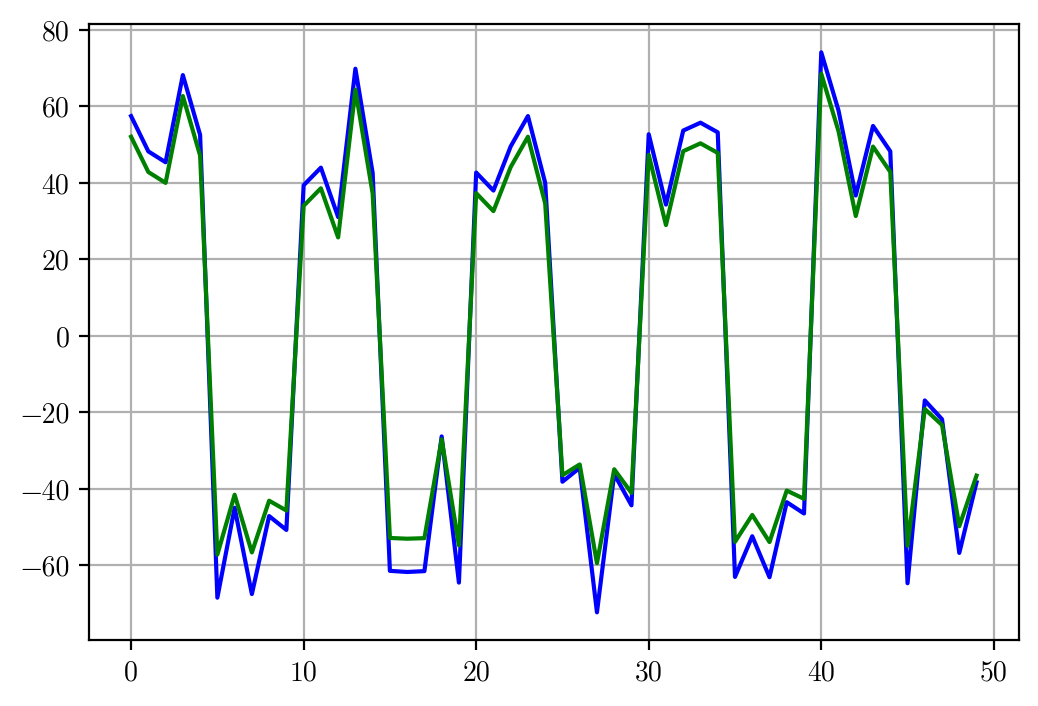

In [29]:
plot((spade_td_s[0] - spade_td_s[0].mean()))
plot((spade_td[0] - spade_td[0].mean()) * 4.6)